## Horn Antenna

This notebook explores the design and discretization of a horn antenna. As part of our coursework, we will focus on generating a high-quality mesh that captures the geometry of the flared aperture, which is critical for accurate signal radiation. We will implement mesh refinement techniques to ensure the model effectively resolves the electromagnetic fields near the transition. The process concludes by exporting the finalized mesh, formatted for use in the Palace solver, where we will ultimately evaluate the antenna’s performance.

In [1]:
import gmsh
import math
import os
import json
from pathlib import Path

from palacetoolkit.geometry import xmin, xmax, ymin, ymax, zmin, zmax, extract_tag
from palacetoolkit.viz import run_with_scrollable_output, view_mesh
from palacetoolkit.mesh import (
    Entity,
    run_meshing_pipeline,
    generate_3d_mesh,
    refine_near_surfaces
)

### Parameters:
 - filename : name of the mesh file to generate (e.g., "horn_antenna.msh")
 - waveguide_length : length of the waveguide section
 - waveguide_width : width of the waveguide section
 - waveguide_height : height of the waveguide section
 - flare_length : length of the flare section
 - flare_width : width of the flare section at the aperture
 - flare_height : height of the flare section at the aperture
 - freq_ghz : frequency of operation in GHz
 - gui : whether to launch the Gmsh GUI for visualization (True/False)
 - mesh_order : The order of interpolation for the finite element basis functions.

In [2]:
filename = "horn_antenna.msh"
waveguide_length = 0.3
waveguide_width = 9.373e-2
waveguide_height = 4.166e-2
flare_length = 0.84
flare_width = 30.0 * 0.0254
flare_height = 23.8 * 0.0254
freq_ghz = 1.8
gui = False
mesh_order = 1 

# Wavelength in free space (lambda_0 = c / f).
c0 = 3e8 
lambda_0 = c0 / (freq_ghz * 1e9)

lc = lambda_0 / 4

### Initializing the Modeling Environment

In [3]:
gmsh.initialize()
gmsh.option.setNumber("General.Verbosity", 5)
gmsh.model.add("horn_antenna")
kernel = gmsh.model.occ

### Geometry Construction and Domain Definition
In this step, we build the horn antenna geometry using the OpenCASCADE kernel. We define the waveguide input and the flared aperture as separate surface loops, connect them to form the solid volume, and finally define a surrounding spherical air domain. The geometry is fragmented to ensure consistent meshing across the waveguide and the radiation domain.

In [4]:
# Waveguide face
kernel.addPoint(-waveguide_width/2, -waveguide_height/2, 0, lc, 1)
kernel.addPoint(waveguide_width/2, -waveguide_height/2, 0, lc, 2)
kernel.addPoint(waveguide_width/2, waveguide_height/2, 0, lc, 3)
kernel.addPoint(-waveguide_width/2, waveguide_height/2, 0, lc, 4)

kernel.addLine(1, 2, 1)
kernel.addLine(2, 3, 2)
kernel.addLine(3, 4, 3)
kernel.addLine(4, 1, 4)

kernel.addCurveLoop([4, 1, 2, 3], 1)
kernel.addPlaneSurface([1], 1)

# Flare face 
kernel.addPoint(-flare_width/2, -flare_height/2, flare_length, lc, 5)
kernel.addPoint(flare_width/2, -flare_height/2, flare_length, lc, 6)
kernel.addPoint(flare_width/2,  flare_height/2, flare_length, lc, 7)
kernel.addPoint(-flare_width/2, flare_height/2, flare_length, lc, 8)

kernel.addLine(5, 6, 5)
kernel.addLine(6, 7, 6)
kernel.addLine(7, 8, 7)
kernel.addLine(8, 5, 8)

kernel.addCurveLoop([8, 5, 6, 7], 2)
kernel.addPlaneSurface([2], 2)

# Connect faces
kernel.addLine(1, 5, 9)  
kernel.addLine(2, 6, 10) 
kernel.addLine(3, 7, 11) 
kernel.addLine(4, 8, 12)

kernel.addCurveLoop([1, 10, -5, -9], 3)
kernel.addPlaneSurface([3], 3)
kernel.addCurveLoop([2, 11, -6, -10], 4)
kernel.addPlaneSurface([4], 4)
kernel.addCurveLoop([3, 12, -7, -11], 5)
kernel.addPlaneSurface([5], 5)
kernel.addCurveLoop([4, 9, -8, -12], 6)
kernel.addPlaneSurface([6], 6)

kernel.addSurfaceLoop([1, 2, 3, 4, 5, 6], 1)

# Volumes
flare = kernel.addVolume([1], 1)
waveguide = kernel.extrude([(2, 1)], 0, 0, -waveguide_length)

# Air domain
outer_radius = max(1.8 * lambda_0, 1.1 * flare_length)
outer_boundary = kernel.addSphere(0, 0, flare_length/2, outer_radius)

# Fragment the geometry to prepare for meshing.
kernel.fragment(kernel.getEntities(), [])
gmsh.model.occ.synchronize()

### Identifying Geometric Entities and Domains
To prepare for simulation, we must categorize the various volumes and surfaces created by the CAD kernel. We define identification functions based on spatial bounds to isolate specific regions—such as the waveguide, the flared aperture, the waveport, and the external air domain. We then use assert statements to verify that our selection logic correctly maps to the expected number of geometric entities, ensuring the model topology is correct before proceeding to the mesh refinement stage.

In [5]:
all_2d_entities = gmsh.model.getEntities(2)
all_3d_entities = gmsh.model.getEntities(3)

def spans_domain(x):
    return math.isclose(xmin(x), -outer_radius, abs_tol=flare_length/100)

def find_2D_outer_sphere():
    return [x for x in all_2d_entities if spans_domain(x)]

def find_3D_domain():
    return [x for x in all_3d_entities if spans_domain(x)]

def is_internal_face(dimtag):
    return math.isclose(zmin(dimtag), 0, abs_tol=1e-6) and math.isclose(zmax(dimtag), 0, abs_tol=1e-6)

def is_external_face(dimtag):
    return math.isclose(zmin(dimtag), -waveguide_length, abs_tol=1e-6) and math.isclose(zmax(dimtag), -waveguide_length, abs_tol=1e-6)

def find_waveport():
    return [x for x in all_2d_entities if is_external_face(x)]

def find_2D_waveguide():
    return [x for x in all_2d_entities if zmin(x) < 0 and zmax(x) < flare_length/3 and not is_internal_face(x) and not is_external_face(x)]

def find_2D_flare():
    return [x for x in all_2d_entities if zmax(x) > flare_length/2 and zmax(x) < 1.5*flare_length and zmin(x) < flare_length/2]

def find_3D_flare():
    return [x for x in all_3d_entities if zmax(x) > 0 and zmax(x) < 1.5*flare_length and zmin(x) > -waveguide_length/2]

def find_3D_waveguide():
    return [x for x in all_3d_entities if zmin(x) < 0 - waveguide_length/2 and zmax(x) < 0 + waveguide_length/2]

# Identify the regions
waveport_dimtags = find_waveport()
outer_sphere_dimtags = find_2D_outer_sphere()
waveguide_dimtags = find_2D_waveguide()
flare_dimtags = find_2D_flare()
waveguide_volume_dimtags = find_3D_waveguide()
domain_dimtags = find_3D_domain()
flare_volume_dimtags = find_3D_flare()


# Verify we found the expected n+umber of entities
assert len(waveport_dimtags) == 1, f"Expected 1 waveport surfaces, found {len(waveport_dimtags)}"
assert len(waveguide_dimtags) == 4, f"Expected 4 waveguide surfaces, found {len(waveguide_dimtags)}"
assert len(flare_dimtags) == 4, f"Expected 4 flare surfaces, found {len(flare_dimtags)}"
assert len(waveguide_volume_dimtags) == 1, f"Expected 1 waveguide volume, found {len(waveguide_volume_dimtags)}"
assert len(flare_volume_dimtags) == 1, f"Expected 1 flare volume, found {len(flare_volume_dimtags)}"
assert len(domain_dimtags) == 1, f"Expected 1 domain volume, found {len(domain_dimtags)}"

### Defining Physical Groups for Simulation
In this step, we assign the previously identified geometric entities to Physical Groups. In the Finite Element Method, these groups act as labels that map the raw geometry to specific simulation attributes. By grouping surfaces and volumes—such as the waveport, the antenna flare, and the surrounding air domain—we enable the Palace solver to correctly assign boundary conditions, excitation sources, and material properties during the analysis phase.

In [6]:
# Create physical groups (these become attributes in Palace)
waveguide_group = gmsh.model.addPhysicalGroup(
    2, [extract_tag(x) for x in waveguide_dimtags], -1, "waveguide"
)

flare_group = gmsh.model.addPhysicalGroup(
    2, [extract_tag(x) for x in flare_dimtags], -1, "flare"
)

outer_boundary_group = gmsh.model.addPhysicalGroup(
    2, [extract_tag(x) for x in outer_sphere_dimtags], -1, "outer_boundary"
)

waveguide_volume_group = gmsh.model.addPhysicalGroup(
    3, [extract_tag(x) for x in waveguide_volume_dimtags], -1, "waveguide_volume"
)

flare_volume_group = gmsh.model.addPhysicalGroup(
    3, [extract_tag(x) for x in flare_volume_dimtags], -1, "flare_volume"
)

domain_group = gmsh.model.addPhysicalGroup(
    3, [extract_tag(x) for x in domain_dimtags], -1, "domain"
)

waveport_group = gmsh.model.addPhysicalGroup(
    2, [extract_tag(x) for x in waveport_dimtags], -1, "waveport"
) 


# Mesh Generation, Optimization, and Export
With the physical domains defined, we now proceed to mesh generation. We apply a graded refinement strategy—using a higher density near the waveport and waveguide surfaces to resolve electromagnetic gradients, and a coarser density in the surrounding air domain to maintain computational efficiency. The final mesh is optimized and exported.



In [7]:
def _generate_horn_mesh():
    refine_near_surfaces([(2, extract_tag(x)) for x in waveport_dimtags + waveguide_dimtags], 
                            lambda_0,
                            ppw_near = 20,
                            ppw_far = 5,
                            transition_distance = 1.5*lambda_0,
                            set_as_background=True)

    gmsh.option.setNumber("Mesh.Algorithm", 6)   # frontal (2D)
    gmsh.option.setNumber("Mesh.Algorithm3D", 1) # Delaunay (3D)

    gmsh.model.mesh.generate(3)
    gmsh.model.mesh.setOrder(mesh_order)
    gmsh.model.mesh.optimize("Netgen")

    gmsh.option.setNumber("Mesh.MshFileVersion", 2.2)
    gmsh.option.setNumber("Mesh.Binary", 0)

    script_dir = os.getcwd()
    output_path = os.path.join(script_dir, filename)
    gmsh.write(output_path)

run_with_scrollable_output(_generate_horn_mesh, title="Horn antenna mesh generation", max_lines=10)

# Optionally launch the Gmsh GUI.
# if gui:  # GUI disabled for docs build.
    # gmsh.fltk.run()  # Disabled for docs build (non-interactive).

# Clean up Gmsh resources.
gmsh.finalize()

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 40%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 50%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 60%] Meshing curve 14 (Line)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 70%] Meshing curve 16 (Line)
Info    : [ 70%] Meshing curve 17 (Line)
Info    : [ 80%] Meshing curve 18 (Line)
Info    : [ 80%] Meshing curve 19 (Line)
Info    : [ 90%] Meshing curve 20 (Line)
Info    : [100%] Meshing curve 22 (Circle)
Info    : Done meshing 1D (Wall 0.0376776s, CPU 0.038683s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Pla

Info    : Done meshing 2D (Wall 0.56563s, CPU 0.556745s)
Info    : Meshing 3D...
Info    : 3D Meshing 3 volumes with 1 connected component
Info    : Tetrahedrizing 15040 nodes...
Info    : Done tetrahedrizing 15048 nodes (Wall 0.146269s, CPU 0.135328s)
Info    : Reconstructing mesh...


Info    :  - Creating surface mesh
Info    :  - Identifying boundary edges
Info    :  - Recovering boundary
Info    : Done reconstructing mesh (Wall 0.441492s, CPU 0.411758s)


Info    : Found volume 3
Info    : Found volume 1
Info    : Found volume 2
Info    : It. 0 - 0 nodes created - worst tet radius 32.2167 (nodes removed 0 0)


Info    : It. 500 - 500 nodes created - worst tet radius 4.56066 (nodes removed 0 0)
Info    : It. 1000 - 1000 nodes created - worst tet radius 3.72653 (nodes removed 0 0)
Info    : It. 1500 - 1500 nodes created - worst tet radius 3.29897 (nodes removed 0 0)
Info    : It. 2000 - 2000 nodes created - worst tet radius 3.01987 (nodes removed 0 0)


...

Info    : 740 swaps performed 
Info    : SwapImprove2  


Info    : 0 swaps performed 
Info    : ImproveMesh 
Info    : Total badness = 463776 


Info    : Total badness = 463269 


Info    : Done optimizing mesh (Wall 27.5587s, CPU 27.4247s)
Info    : Writing '/home/martin/Desktop/PalaceToolkit/docs/examples/horn_antenna.msh'...


Info    : Done writing '/home/martin/Desktop/PalaceToolkit/docs/examples/horn_antenna.msh'


Loading mesh file: horn_antenna.msh
Groups to render transparent: ['outer_boundary']



Mesh loaded successfully with 2 cell blocks
Found 28984 triangles total
Physical group tags in mesh: {1: 'waveguide', 2: 'flare', 3: 'outer_boundary', 7: 'waveport'}



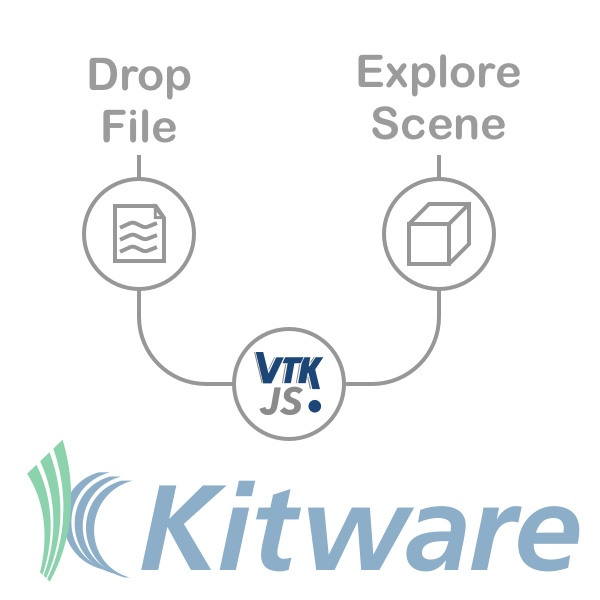

In [8]:
import pyvista as pv

# trame for interactive visualization in the notebook.
pv.set_jupyter_backend("trame")

# Visualize the mesh in the notebook.
if mesh_order == 1:
    view_mesh(filename, transparent_groups=["outer_boundary"])

### Defining Physical Group Mappings
To ensure clarity and maintainability when configuring the simulation, we map each physical group's numerical ID to a descriptive label. This dictionary acts as a lookup table, allowing us to easily reference specific domains—such as the waveport, farfield boundary, or interior volumes—by name rather than by index. This structured approach simplifies the process of setting up boundary conditions and material assignments in the subsequent Palace simulation input files.

In [9]:
pg_map = {
    "waveport": waveport_group,
    "waveguide_2D": waveguide_group,
    "flare_2D": flare_group,
    "farfield": outer_boundary_group,
    "waveguide_volume": waveguide_volume_group,
    "flare_volume": flare_volume_group,
    "domain": domain_group
}

### Output configuration for Palace JSON input file

In [10]:
freq_min = 1.8
freq_max = 1.8
freq_step = 0.1

# absorbing boundary condition order (1 for first-order ABC, 2 for second-order ABC, etc.)
abc_order = 2
solver_order = 2

output_file = "horn_antenna.json"

### Generating the Palace Configuration File
Finally, we assemble the simulation parameters into a JSON configuration file. This dictionary defines the electromagnetic problem type, assigns material properties to our physical volumes, sets boundary conditions (such as the WavePort excitation and absorbing boundaries), and configures the solver's convergence criteria. This file serves as the definitive input for Palace to execute the full-wave analysis of the horn antenna.

In [11]:
output_stem = Path(filename).stem

config = {
    "Problem": {"Type": "Driven", "Verbose": 2, "Output": f"/work/postpro/{output_stem}"},
    "Model": {"Mesh": f"/work/{filename}", "L0": 1.0},
    "Domains": {
        "Materials": [{
            "Attributes": [pg_map["waveguide_volume"], pg_map["flare_volume"], pg_map["domain"]],
            "Permeability": 1.0, "Permittivity": 1.0, "LossTan": 0.0
        }]
    },
    "Boundaries": {
        "Absorbing": {"Attributes": [pg_map["farfield"]], "Order": abc_order},
        "PEC": {"Attributes": [pg_map["waveguide_2D"], pg_map["flare_2D"]]},
        "Postprocessing": {
            "FarField": {
                "Attributes": [pg_map["farfield"]],
                "NSample": 64000 
            }
        },
        "WavePort": [{
            "Index": 1, "Attributes": [pg_map["waveport"]],
            "Mode": 1, "Offset": 0.0, "Excitation": True
        }]
    },
    "Solver": {
        "Order": solver_order, "Device": "CPU",
        "Driven": {"MinFreq": freq_min, "MaxFreq": freq_max, "FreqStep": freq_step, "SaveStep": 1, "AdaptiveTol": 0.0001},
        "Linear": {"Type": "Default", "KSPType": "GMRES", "Tol": 1e-7, "MaxIts": 3000, "MaxSize": 1000, "ComplexCoarseSolve": True}
    }
}

script_dir = os.getcwd()
config_path = os.path.join(script_dir, output_file)
with open(config_path, "w") as f: json.dump(config, f, indent=2)